# Final Grade Prediction - Model Training and Evaluation

This notebook trains multiple regression models on the OULAD dataset and evaluates them on the UCI dataset for cross-validation.

## Workflow:
1. Load prepared datasets (OULAD and UCI)
2. Split OULAD into train/validation sets
3. Train multiple regression models
4. Evaluate models on validation set (OULAD)
5. Evaluate best model on test set (UCI - complete dataset)
6. Compare model performance and select the best model


## 1. Import Libraries and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Prepared Datasets


In [2]:
# Load prepared datasets
import os
import json

# Find prepared data directory (relative to this notebook)
prepared_data_dir = 'prepared_data'
if not os.path.exists(prepared_data_dir):
    raise FileNotFoundError(f"Prepared data directory not found: {prepared_data_dir}. Please run data_preparation.ipynb first.")

# Load datasets
oulad_path = os.path.join(prepared_data_dir, 'oulad_final_grade_prepared.csv')
uci_path = os.path.join(prepared_data_dir, 'uci_final_grade_prepared.csv')
info_path = os.path.join(prepared_data_dir, 'feature_info.json')

df_oulad = pd.read_csv(oulad_path)
df_uci = pd.read_csv(uci_path)

# Load feature information
with open(info_path, 'r') as f:
    feature_info = json.load(f)

print(f"OULAD dataset: {df_oulad.shape[0]} rows × {df_oulad.shape[1]} columns")
print(f"UCI dataset: {df_uci.shape[0]} rows × {df_uci.shape[1]} columns")
print(f"\nOULAD columns: {list(df_oulad.columns)}")
print(f"\nUCI columns: {list(df_uci.columns)}")


OULAD dataset: 25820 rows × 10 columns
UCI dataset: 1044 rows × 9 columns

OULAD columns: ['gender', 'age_numeric', 'engagement', 'academic_history', 'education_background', 'absences_normalized', 'support_indicator', 'final_grade', 'final_grade_normalized', 'final_grade_0_20']

UCI columns: ['gender', 'age_numeric', 'engagement', 'academic_history', 'education_background', 'absences_normalized', 'support_indicator', 'final_grade', 'final_grade_normalized']


## 3. Prepare Features and Targets


In [3]:
# Get common features (excluding target variables)
common_features = feature_info['common_features']
print(f"Common features: {common_features}")

# Prepare OULAD dataset
# Use normalized target (0-1 scale) for consistency
X_oulad = df_oulad[common_features].copy()
y_oulad = df_oulad['final_grade_normalized'].copy()

# Prepare UCI dataset (test set)
X_uci = df_uci[common_features].copy()
y_uci = df_uci['final_grade_normalized'].copy()

print(f"\nOULAD features shape: {X_oulad.shape}")
print(f"OULAD target shape: {y_oulad.shape}")
print(f"OULAD target range: [{y_oulad.min():.3f}, {y_oulad.max():.3f}]")

print(f"\nUCI features shape: {X_uci.shape}")
print(f"UCI target shape: {y_uci.shape}")
print(f"UCI target range: [{y_uci.min():.3f}, {y_uci.max():.3f}]")


Common features: ['absences_normalized', 'academic_history', 'age_numeric', 'education_background', 'engagement', 'gender', 'support_indicator']

OULAD features shape: (25820, 7)
OULAD target shape: (25820,)
OULAD target range: [0.000, 1.000]

UCI features shape: (1044, 7)
UCI target shape: (1044,)
UCI target range: [0.000, 1.000]


## 4. Preprocess Features


In [4]:
# Handle categorical features (gender)
# Encode gender for both datasets
le_gender = LabelEncoder()

# Fit on combined data to ensure same encoding
all_genders = pd.concat([X_oulad['gender'], X_uci['gender']]).unique()
le_gender.fit(all_genders)

X_oulad['gender_encoded'] = le_gender.transform(X_oulad['gender'])
X_uci['gender_encoded'] = le_gender.transform(X_uci['gender'])

# Drop original gender column
X_oulad = X_oulad.drop('gender', axis=1)
X_uci = X_uci.drop('gender', axis=1)

# Update feature list
numeric_features = [f for f in common_features if f != 'gender'] + ['gender_encoded']

# Check for missing values
print("Missing values in OULAD features:")
print(X_oulad.isnull().sum())
print("\nMissing values in UCI features:")
print(X_uci.isnull().sum())

# Fill any missing values (shouldn't be any, but just in case)
X_oulad = X_oulad.fillna(X_oulad.median())
X_uci = X_uci.fillna(X_oulad.median())  # Use OULAD median for consistency

print(f"\nFinal feature set: {numeric_features}")
print(f"Number of features: {len(numeric_features)}")


Missing values in OULAD features:
absences_normalized     0
academic_history        0
age_numeric             0
education_background    0
engagement              0
support_indicator       0
gender_encoded          0
dtype: int64

Missing values in UCI features:
absences_normalized     0
academic_history        0
age_numeric             0
education_background    0
engagement              0
support_indicator       0
gender_encoded          0
dtype: int64

Final feature set: ['absences_normalized', 'academic_history', 'age_numeric', 'education_background', 'engagement', 'support_indicator', 'gender_encoded']
Number of features: 7


## 5. Scale Features


In [5]:
# Scale features using StandardScaler
# Fit scaler on OULAD training data only
scaler = StandardScaler()

# Split OULAD first to fit scaler only on training data
X_oulad_train, X_oulad_val, y_oulad_train, y_oulad_val = train_test_split(
    X_oulad, y_oulad, test_size=0.2, random_state=42
)

# Fit scaler on training data
scaler.fit(X_oulad_train[numeric_features])

# Transform all datasets
X_oulad_train_scaled = pd.DataFrame(
    scaler.transform(X_oulad_train[numeric_features]),
    columns=numeric_features,
    index=X_oulad_train.index
)
X_oulad_val_scaled = pd.DataFrame(
    scaler.transform(X_oulad_val[numeric_features]),
    columns=numeric_features,
    index=X_oulad_val.index
)
X_uci_scaled = pd.DataFrame(
    scaler.transform(X_uci[numeric_features]),
    columns=numeric_features,
    index=X_uci.index
)

print(f"OULAD train set: {X_oulad_train_scaled.shape[0]} samples")
print(f"OULAD validation set: {X_oulad_val_scaled.shape[0]} samples")
print(f"UCI test set: {X_uci_scaled.shape[0]} samples")


OULAD train set: 20656 samples
OULAD validation set: 5164 samples
UCI test set: 1044 samples


## 6. Define Models and Evaluation Metrics


In [6]:
# Define models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5)
}

# Evaluation metrics function
def evaluate_model(y_true, y_pred, model_name=""):
    """Calculate and return regression metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (handle division by zero)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    }
    
    return metrics

print(f"Models to evaluate: {list(models.keys())}")


Models to evaluate: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest', 'Gradient Boosting', 'SVR', 'K-Nearest Neighbors']


## 7. Train and Evaluate Models on Validation Set


In [7]:
# Train and evaluate all models
results_val = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Train model
    model.fit(X_oulad_train_scaled, y_oulad_train)
    
    # Predict on validation set
    y_val_pred = model.predict(X_oulad_val_scaled)
    
    # Evaluate
    metrics = evaluate_model(y_oulad_val, y_val_pred, name)
    results_val[name] = {
        'model': model,
        'metrics': metrics,
        'predictions': y_val_pred
    }
    
    print(f"Validation Metrics:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

print(f"\n{'='*60}")
print("Validation Results Summary")
print(f"{'='*60}")



Training Linear Regression...
Validation Metrics:
  MSE: 0.0252
  RMSE: 0.1589
  MAE: 0.1231
  R²: 0.1263
  MAPE: 8539942.8176

Training Ridge Regression...
Validation Metrics:
  MSE: 0.0252
  RMSE: 0.1589
  MAE: 0.1231
  R²: 0.1263
  MAPE: 8539972.9664

Training Lasso Regression...
Validation Metrics:
  MSE: 0.0289
  RMSE: 0.1699
  MAE: 0.1335
  R²: -0.0000
  MAPE: 9517594.3517

Training Random Forest...
Validation Metrics:
  MSE: 0.0293
  RMSE: 0.1713
  MAE: 0.1326
  R²: -0.0157
  MAPE: 8068119.4625

Training Gradient Boosting...
Validation Metrics:
  MSE: 0.0244
  RMSE: 0.1564
  MAE: 0.1216
  R²: 0.1536
  MAPE: 7872785.2548

Training SVR...
Validation Metrics:
  MSE: 0.0249
  RMSE: 0.1578
  MAE: 0.1212
  R²: 0.1383
  MAPE: 8167218.6573

Training K-Nearest Neighbors...
Validation Metrics:
  MSE: 0.0298
  RMSE: 0.1728
  MAE: 0.1342
  R²: -0.0335
  MAPE: 7763618.8408

Validation Results Summary


In [8]:
# Create results DataFrame for comparison
results_df = pd.DataFrame({
    name: results_val[name]['metrics'] 
    for name in results_val.keys()
}).T

# Sort by R² score (higher is better)
results_df = results_df.sort_values('R²', ascending=False)

print(results_df.round(4))


                        MSE    RMSE     MAE      R²          MAPE
Gradient Boosting    0.0244  0.1564  0.1216  0.1536  7.872785e+06
SVR                  0.0249  0.1578  0.1212  0.1383  8.167219e+06
Linear Regression    0.0252  0.1589  0.1231  0.1263  8.539943e+06
Ridge Regression     0.0252  0.1589  0.1231  0.1263  8.539973e+06
Lasso Regression     0.0289  0.1699  0.1335 -0.0000  9.517594e+06
Random Forest        0.0293  0.1713  0.1326 -0.0157  8.068119e+06
K-Nearest Neighbors  0.0298  0.1728  0.1342 -0.0335  7.763619e+06


## 8. Select Best Model


In [9]:
# Select best model based on R² score (can also use RMSE or MAE)
best_model_name = results_df.index[0]
best_model = results_val[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"Validation R²: {results_df.loc[best_model_name, 'R²']:.4f}")
print(f"Validation RMSE: {results_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"Validation MAE: {results_df.loc[best_model_name, 'MAE']:.4f}")


Best Model: Gradient Boosting
Validation R²: 0.1536
Validation RMSE: 0.1564
Validation MAE: 0.1216


## 9. Evaluate Best Model on Test Set (UCI)


In [10]:
# Evaluate best model on UCI test set
print(f"\n{'='*60}")
print(f"Evaluating {best_model_name} on UCI Test Set")
print(f"{'='*60}")

# Predict on test set
y_uci_pred = best_model.predict(X_uci_scaled)

# Evaluate
test_metrics = evaluate_model(y_uci, y_uci_pred, best_model_name)

print(f"\nTest Set Metrics (UCI):")
for metric_name, value in test_metrics.items():
    print(f"  {metric_name}: {value:.4f}")

# Compare with validation metrics
print(f"\n{'='*60}")
print("Validation vs Test Set Comparison")
print(f"{'='*60}")
comparison_df = pd.DataFrame({
    'Validation': results_val[best_model_name]['metrics'],
    'Test (UCI)': test_metrics
})
print(comparison_df.round(4))



Evaluating Gradient Boosting on UCI Test Set

Test Set Metrics (UCI):
  MSE: 0.0698
  RMSE: 0.2641
  MAE: 0.2091
  R²: -0.8703
  MAPE: 362266913.7985

Validation vs Test Set Comparison
        Validation    Test (UCI)
MSE   2.440000e-02  6.980000e-02
RMSE  1.564000e-01  2.641000e-01
MAE   1.216000e-01  2.091000e-01
R²    1.536000e-01 -8.703000e-01
MAPE  7.872785e+06  3.622669e+08


## 10. Visualize Results


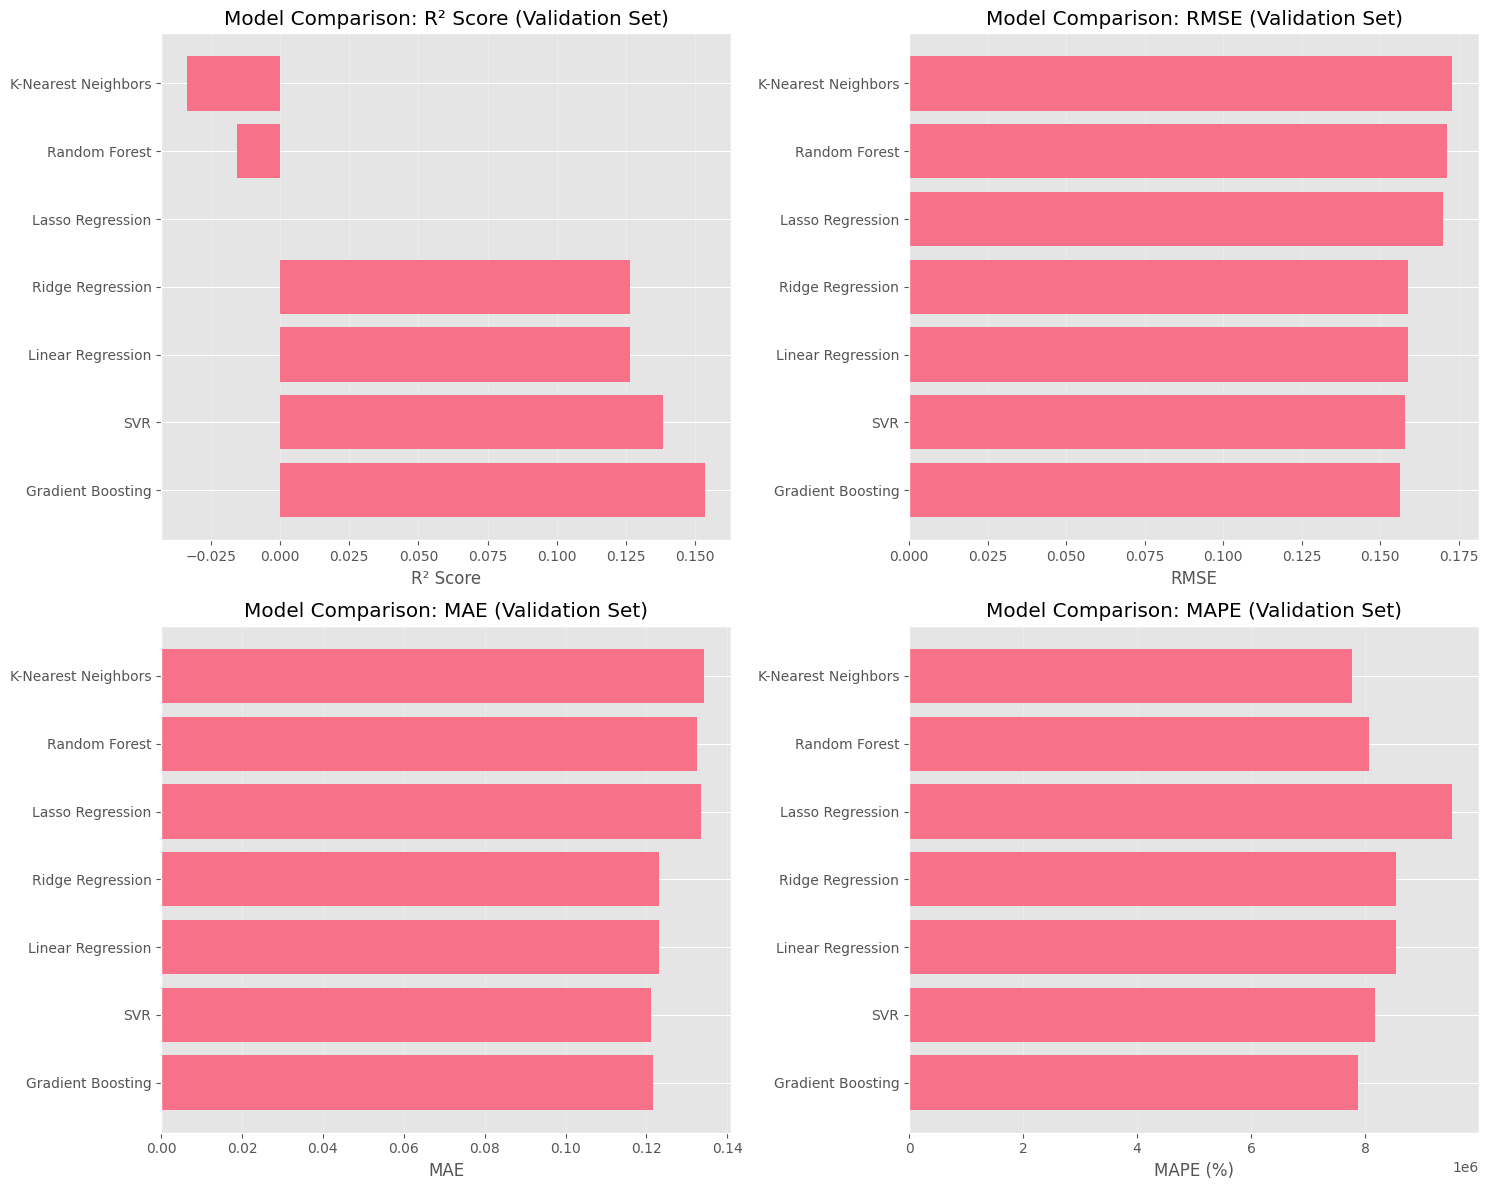

In [11]:
# Plot 1: Model Comparison (R² scores)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# R² comparison
axes[0, 0].barh(results_df.index, results_df['R²'])
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('Model Comparison: R² Score (Validation Set)')
axes[0, 0].grid(axis='x', alpha=0.3)

# RMSE comparison
axes[0, 1].barh(results_df.index, results_df['RMSE'])
axes[0, 1].set_xlabel('RMSE')
axes[0, 1].set_title('Model Comparison: RMSE (Validation Set)')
axes[0, 1].grid(axis='x', alpha=0.3)

# MAE comparison
axes[1, 0].barh(results_df.index, results_df['MAE'])
axes[1, 0].set_xlabel('MAE')
axes[1, 0].set_title('Model Comparison: MAE (Validation Set)')
axes[1, 0].grid(axis='x', alpha=0.3)

# MAPE comparison
axes[1, 1].barh(results_df.index, results_df['MAPE'])
axes[1, 1].set_xlabel('MAPE (%)')
axes[1, 1].set_title('Model Comparison: MAPE (Validation Set)')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


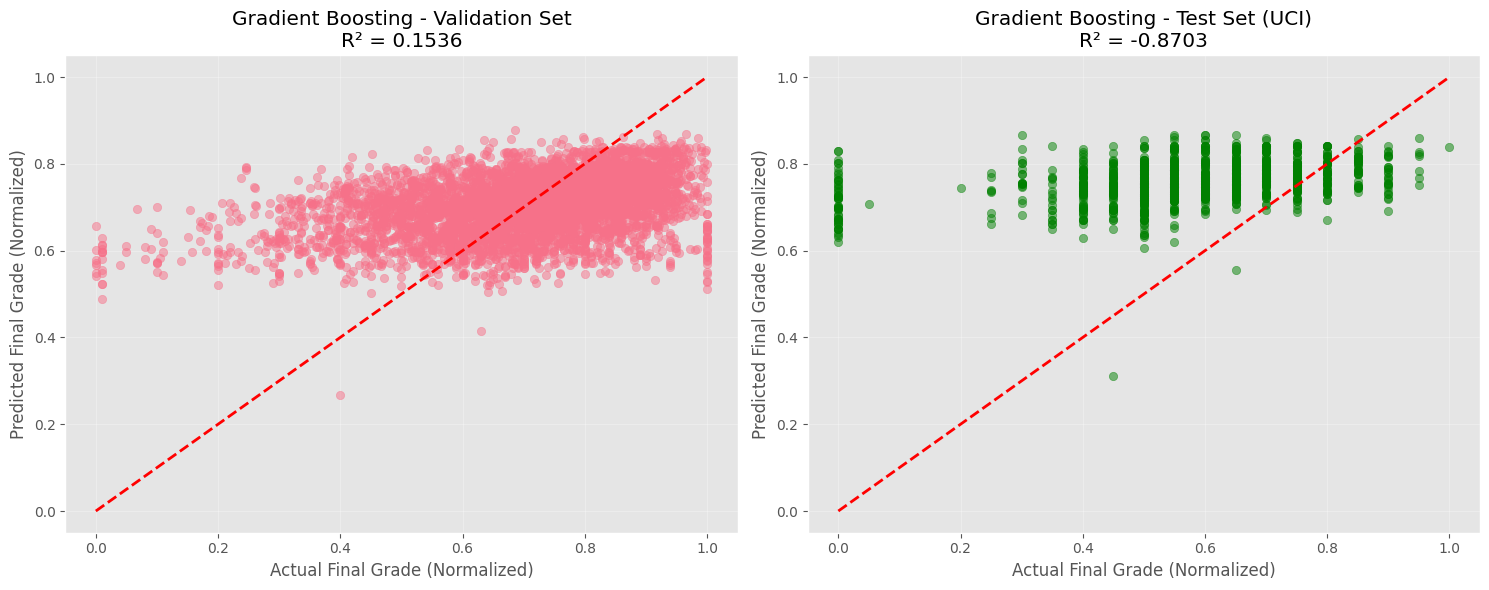

In [12]:
# Plot 2: Predicted vs Actual (Best Model)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Validation set
axes[0].scatter(y_oulad_val, results_val[best_model_name]['predictions'], alpha=0.5)
axes[0].plot([y_oulad_val.min(), y_oulad_val.max()], 
             [y_oulad_val.min(), y_oulad_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Final Grade (Normalized)')
axes[0].set_ylabel('Predicted Final Grade (Normalized)')
axes[0].set_title(f'{best_model_name} - Validation Set\nR² = {results_val[best_model_name]["metrics"]["R²"]:.4f}')
axes[0].grid(alpha=0.3)

# Test set (UCI)
axes[1].scatter(y_uci, y_uci_pred, alpha=0.5, color='green')
axes[1].plot([y_uci.min(), y_uci.max()], 
             [y_uci.min(), y_uci.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Final Grade (Normalized)')
axes[1].set_ylabel('Predicted Final Grade (Normalized)')
axes[1].set_title(f'{best_model_name} - Test Set (UCI)\nR² = {test_metrics["R²"]:.4f}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


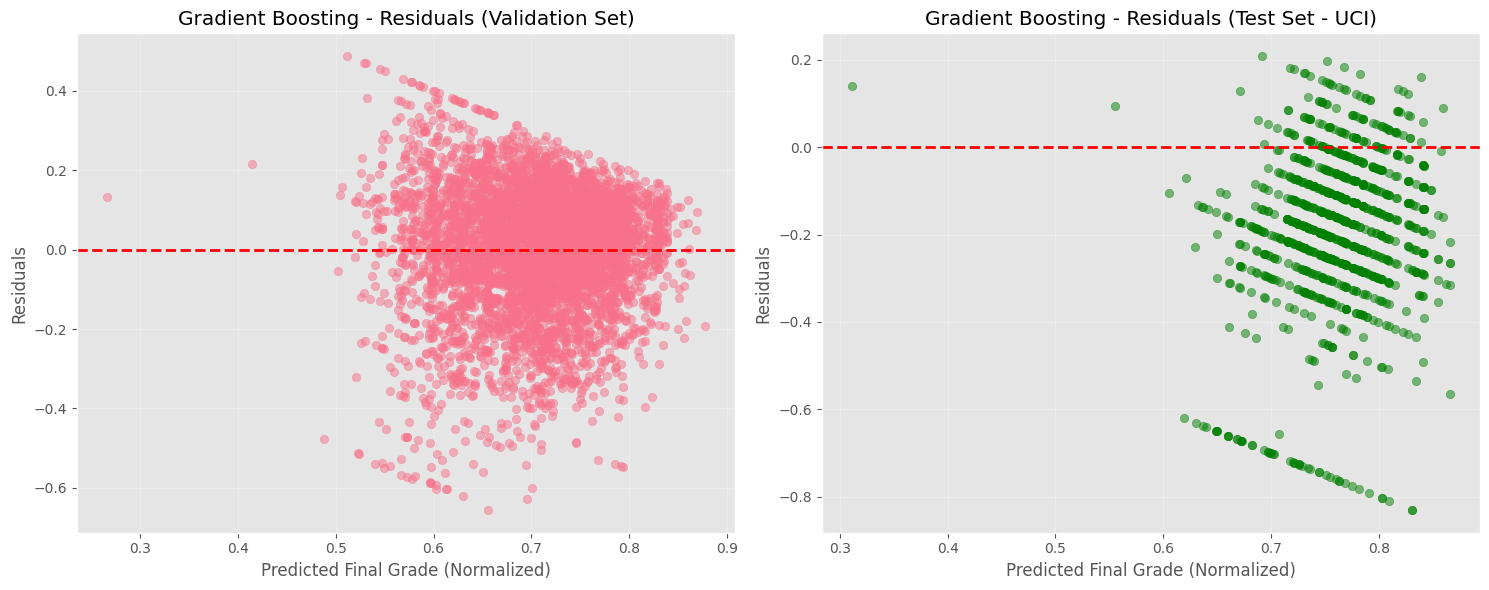

In [13]:
# Plot 3: Residuals Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Validation set residuals
val_residuals = y_oulad_val - results_val[best_model_name]['predictions']
axes[0].scatter(results_val[best_model_name]['predictions'], val_residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Final Grade (Normalized)')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'{best_model_name} - Residuals (Validation Set)')
axes[0].grid(alpha=0.3)

# Test set residuals
test_residuals = y_uci - y_uci_pred
axes[1].scatter(y_uci_pred, test_residuals, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Final Grade (Normalized)')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'{best_model_name} - Residuals (Test Set - UCI)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Feature Importance (if applicable)



Feature Importance (Gradient Boosting):
             feature  importance
 absences_normalized    0.484292
          engagement    0.319845
education_background    0.061308
      gender_encoded    0.051493
   support_indicator    0.042153
    academic_history    0.034538
         age_numeric    0.006371


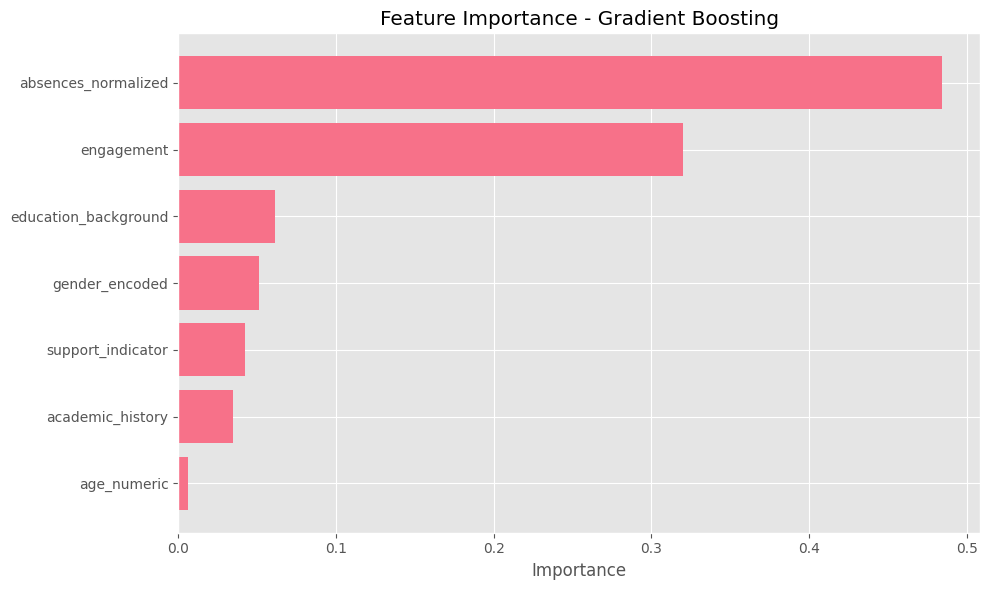

In [14]:
# Get feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': numeric_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nFeature Importance ({best_model_name}):")
    print(feature_importance.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # For linear models, use absolute coefficients
    feature_importance = pd.DataFrame({
        'feature': numeric_features,
        'coefficient': best_model.coef_
    })
    feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
    feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)
    
    print(f"\nFeature Coefficients ({best_model_name}):")
    print(feature_importance[['feature', 'coefficient']].to_string(index=False))
    
    # Plot coefficients
    plt.figure(figsize=(10, 6))
    colors = ['red' if x < 0 else 'blue' for x in feature_importance['coefficient']]
    plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
    plt.xlabel('Coefficient')
    plt.title(f'Feature Coefficients - {best_model_name}')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\n{best_model_name} does not provide feature importance/coefficients.")


## 12. Summary and Conclusions


In [15]:
print("="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nBest Model: {best_model_name}")
print(f"\nTraining Set: OULAD (split into train/validation)")
print(f"  - Training samples: {X_oulad_train_scaled.shape[0]}")
print(f"  - Validation samples: {X_oulad_val_scaled.shape[0]}")
print(f"\nTest Set: UCI (complete dataset)")
print(f"  - Test samples: {X_uci_scaled.shape[0]}")

print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"\nValidation Set Performance:")
for metric, value in results_val[best_model_name]['metrics'].items():
    print(f"  {metric}: {value:.4f}")

print(f"\nTest Set Performance (UCI):")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

print(f"\n{'='*60}")
print("KEY FINDINGS")
print(f"{'='*60}")
print(f"1. Best performing model: {best_model_name}")
print(f"2. Validation R²: {results_val[best_model_name]['metrics']['R²']:.4f}")
print(f"3. Test R² (cross-dataset): {test_metrics['R²']:.4f}")
print(f"4. Performance gap: {abs(results_val[best_model_name]['metrics']['R²'] - test_metrics['R²']):.4f}")
print(f"5. Model successfully trained on OULAD and evaluated on UCI dataset")


FINAL SUMMARY

Best Model: Gradient Boosting

Training Set: OULAD (split into train/validation)
  - Training samples: 20656
  - Validation samples: 5164

Test Set: UCI (complete dataset)
  - Test samples: 1044

PERFORMANCE METRICS

Validation Set Performance:
  MSE: 0.0244
  RMSE: 0.1564
  MAE: 0.1216
  R²: 0.1536
  MAPE: 7872785.2548

Test Set Performance (UCI):
  MSE: 0.0698
  RMSE: 0.2641
  MAE: 0.2091
  R²: -0.8703
  MAPE: 362266913.7985

KEY FINDINGS
1. Best performing model: Gradient Boosting
2. Validation R²: 0.1536
3. Test R² (cross-dataset): -0.8703
4. Performance gap: 1.0239
5. Model successfully trained on OULAD and evaluated on UCI dataset


## 13. Reverse Cross-Validation: Train on UCI, Test on OULAD

This section performs the reverse experiment: training models on UCI dataset and evaluating on OULAD dataset.


### 13.1 Prepare UCI for Training and OULAD for Testing


In [16]:
# Prepare UCI dataset for training (split into train/validation)
# Use the original UCI features that we prepared earlier
X_uci_train, X_uci_val, y_uci_train, y_uci_val = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

# OULAD will be the complete test set
X_oulad_test = X_oulad.copy()
y_oulad_test = y_oulad.copy()

# Create a new scaler for UCI training data
scaler_reverse = StandardScaler()
scaler_reverse.fit(X_uci_train[numeric_features])

# Transform all datasets
X_uci_train_scaled_rev = pd.DataFrame(
    scaler_reverse.transform(X_uci_train[numeric_features]),
    columns=numeric_features,
    index=X_uci_train.index
)
X_uci_val_scaled_rev = pd.DataFrame(
    scaler_reverse.transform(X_uci_val[numeric_features]),
    columns=numeric_features,
    index=X_uci_val.index
)
X_oulad_test_scaled_rev = pd.DataFrame(
    scaler_reverse.transform(X_oulad_test[numeric_features]),
    columns=numeric_features,
    index=X_oulad_test.index
)

print(f"UCI train set: {X_uci_train_scaled_rev.shape[0]} samples")
print(f"UCI validation set: {X_uci_val_scaled_rev.shape[0]} samples")
print(f"OULAD test set: {X_oulad_test_scaled_rev.shape[0]} samples")


UCI train set: 835 samples
UCI validation set: 209 samples
OULAD test set: 25820 samples


### 13.2 Train and Evaluate Models on UCI Validation Set


In [17]:
# Train and evaluate all models on UCI validation set
results_val_reverse = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name} on UCI...")
    print(f"{'='*60}")
    
    # Create a fresh model instance
    from sklearn.base import clone
    model_reverse = clone(model)
    
    # Train model on UCI training data
    model_reverse.fit(X_uci_train_scaled_rev, y_uci_train)
    
    # Predict on UCI validation set
    y_uci_val_pred = model_reverse.predict(X_uci_val_scaled_rev)
    
    # Evaluate
    metrics = evaluate_model(y_uci_val, y_uci_val_pred, name)
    results_val_reverse[name] = {
        'model': model_reverse,
        'metrics': metrics,
        'predictions': y_uci_val_pred
    }
    
    print(f"Validation Metrics (UCI):")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

print(f"\n{'='*60}")
print("Validation Results Summary (UCI)")
print(f"{'='*60}")



Training Linear Regression on UCI...
Validation Metrics (UCI):
  MSE: 0.0363
  RMSE: 0.1904
  MAE: 0.1396
  R²: 0.0620
  MAPE: 286841650.1154

Training Ridge Regression on UCI...
Validation Metrics (UCI):
  MSE: 0.0362
  RMSE: 0.1904
  MAE: 0.1396
  R²: 0.0622
  MAPE: 286847202.3817

Training Lasso Regression on UCI...
Validation Metrics (UCI):
  MSE: 0.0390
  RMSE: 0.1974
  MAE: 0.1469
  R²: -0.0082
  MAPE: 300346700.9699

Training Random Forest on UCI...
Validation Metrics (UCI):
  MSE: 0.0379
  RMSE: 0.1946
  MAE: 0.1396
  R²: 0.0201
  MAPE: 209722947.2865

Training Gradient Boosting on UCI...
Validation Metrics (UCI):
  MSE: 0.0341
  RMSE: 0.1848
  MAE: 0.1358
  R²: 0.1167
  MAPE: 224162574.3162

Training SVR on UCI...
Validation Metrics (UCI):
  MSE: 0.0370
  RMSE: 0.1923
  MAE: 0.1414
  R²: 0.0428
  MAPE: 242050754.0619

Training K-Nearest Neighbors on UCI...
Validation Metrics (UCI):
  MSE: 0.0362
  RMSE: 0.1903
  MAE: 0.1421
  R²: 0.0632
  MAPE: 240191413.1345

Validation Resu

In [18]:
# Create results DataFrame for comparison
results_df_reverse = pd.DataFrame({
    name: results_val_reverse[name]['metrics'] 
    for name in results_val_reverse.keys()
}).T

# Sort by R² score (higher is better)
results_df_reverse = results_df_reverse.sort_values('R²', ascending=False)

print(results_df_reverse.round(4))


                        MSE    RMSE     MAE      R²          MAPE
Gradient Boosting    0.0341  0.1848  0.1358  0.1167  2.241626e+08
K-Nearest Neighbors  0.0362  0.1903  0.1421  0.0632  2.401914e+08
Ridge Regression     0.0362  0.1904  0.1396  0.0622  2.868472e+08
Linear Regression    0.0363  0.1904  0.1396  0.0620  2.868417e+08
SVR                  0.0370  0.1923  0.1414  0.0428  2.420508e+08
Random Forest        0.0379  0.1946  0.1396  0.0201  2.097229e+08
Lasso Regression     0.0390  0.1974  0.1469 -0.0082  3.003467e+08


### 13.3 Select Best Model and Evaluate on OULAD Test Set


In [19]:
# Select best model based on R² score on UCI validation set
best_model_name_reverse = results_df_reverse.index[0]
best_model_reverse = results_val_reverse[best_model_name_reverse]['model']

print(f"Best Model (trained on UCI): {best_model_name_reverse}")
print(f"Validation R² (UCI): {results_df_reverse.loc[best_model_name_reverse, 'R²']:.4f}")
print(f"Validation RMSE (UCI): {results_df_reverse.loc[best_model_name_reverse, 'RMSE']:.4f}")
print(f"Validation MAE (UCI): {results_df_reverse.loc[best_model_name_reverse, 'MAE']:.4f}")

# Evaluate best model on OULAD test set
print(f"\n{'='*60}")
print(f"Evaluating {best_model_name_reverse} on OULAD Test Set")
print(f"{'='*60}")

# Predict on OULAD test set
y_oulad_test_pred = best_model_reverse.predict(X_oulad_test_scaled_rev)

# Evaluate
test_metrics_reverse = evaluate_model(y_oulad_test, y_oulad_test_pred, best_model_name_reverse)

print(f"\nTest Set Metrics (OULAD):")
for metric_name, value in test_metrics_reverse.items():
    print(f"  {metric_name}: {value:.4f}")

# Compare with validation metrics
print(f"\n{'='*60}")
print("Validation (UCI) vs Test Set (OULAD) Comparison")
print(f"{'='*60}")
comparison_df_reverse = pd.DataFrame({
    'Validation (UCI)': results_val_reverse[best_model_name_reverse]['metrics'],
    'Test (OULAD)': test_metrics_reverse
})
print(comparison_df_reverse.round(4))


Best Model (trained on UCI): Gradient Boosting
Validation R² (UCI): 0.1167
Validation RMSE (UCI): 0.1848
Validation MAE (UCI): 0.1358

Evaluating Gradient Boosting on OULAD Test Set

Test Set Metrics (OULAD):
  MSE: 0.0682
  RMSE: 0.2612
  MAE: 0.2252
  R²: -1.3443
  MAPE: 8985142.5761

Validation (UCI) vs Test Set (OULAD) Comparison
      Validation (UCI)  Test (OULAD)
MSE       3.410000e-02  6.820000e-02
RMSE      1.848000e-01  2.612000e-01
MAE       1.358000e-01  2.252000e-01
R²        1.167000e-01 -1.344300e+00
MAPE      2.241626e+08  8.985143e+06


### 13.4 Visualize Reverse Cross-Validation Results


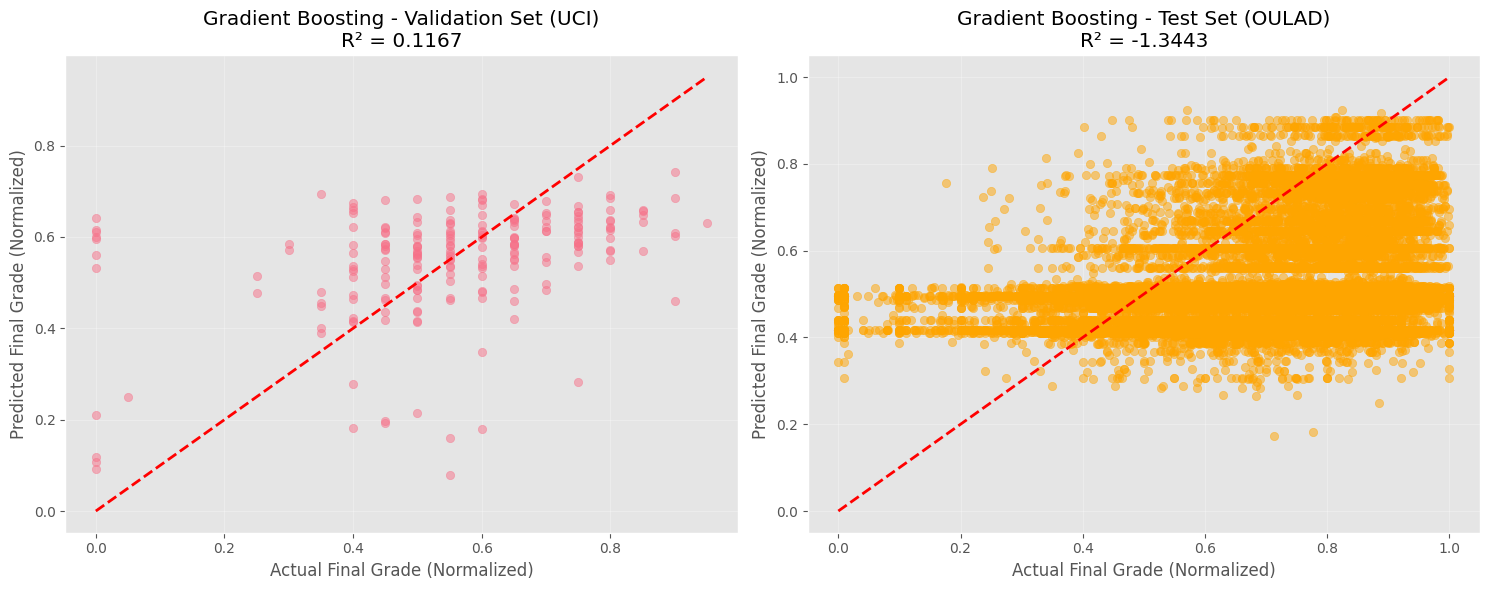

In [20]:
# Plot: Predicted vs Actual (Best Model - Reverse)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Validation set (UCI)
axes[0].scatter(y_uci_val, results_val_reverse[best_model_name_reverse]['predictions'], alpha=0.5)
axes[0].plot([y_uci_val.min(), y_uci_val.max()], 
             [y_uci_val.min(), y_uci_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Final Grade (Normalized)')
axes[0].set_ylabel('Predicted Final Grade (Normalized)')
axes[0].set_title(f'{best_model_name_reverse} - Validation Set (UCI)\nR² = {results_val_reverse[best_model_name_reverse]["metrics"]["R²"]:.4f}')
axes[0].grid(alpha=0.3)

# Test set (OULAD)
axes[1].scatter(y_oulad_test, y_oulad_test_pred, alpha=0.5, color='orange')
axes[1].plot([y_oulad_test.min(), y_oulad_test.max()], 
             [y_oulad_test.min(), y_oulad_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Final Grade (Normalized)')
axes[1].set_ylabel('Predicted Final Grade (Normalized)')
axes[1].set_title(f'{best_model_name_reverse} - Test Set (OULAD)\nR² = {test_metrics_reverse["R²"]:.4f}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 13.5 Summary of Reverse Cross-Validation


In [21]:
print("="*60)
print("REVERSE CROSS-VALIDATION SUMMARY")
print("="*60)
print(f"\nBest Model: {best_model_name_reverse}")
print(f"\nTraining Set: UCI (split into train/validation)")
print(f"  - Training samples: {X_uci_train_scaled_rev.shape[0]}")
print(f"  - Validation samples: {X_uci_val_scaled_rev.shape[0]}")
print(f"\nTest Set: OULAD (complete dataset)")
print(f"  - Test samples: {X_oulad_test_scaled_rev.shape[0]}")

print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"\nValidation Set Performance (UCI):")
for metric, value in results_val_reverse[best_model_name_reverse]['metrics'].items():
    print(f"  {metric}: {value:.4f}")

print(f"\nTest Set Performance (OULAD):")
for metric, value in test_metrics_reverse.items():
    print(f"  {metric}: {value:.4f}")

print(f"\n{'='*60}")
print("KEY FINDINGS")
print(f"{'='*60}")
print(f"1. Best performing model: {best_model_name_reverse}")
print(f"2. Validation R² (UCI): {results_val_reverse[best_model_name_reverse]['metrics']['R²']:.4f}")
print(f"3. Test R² (cross-dataset on OULAD): {test_metrics_reverse['R²']:.4f}")
print(f"4. Performance gap: {abs(results_val_reverse[best_model_name_reverse]['metrics']['R²'] - test_metrics_reverse['R²']):.4f}")
print(f"5. Model successfully trained on UCI and evaluated on OULAD dataset")


REVERSE CROSS-VALIDATION SUMMARY

Best Model: Gradient Boosting

Training Set: UCI (split into train/validation)
  - Training samples: 835
  - Validation samples: 209

Test Set: OULAD (complete dataset)
  - Test samples: 25820

PERFORMANCE METRICS

Validation Set Performance (UCI):
  MSE: 0.0341
  RMSE: 0.1848
  MAE: 0.1358
  R²: 0.1167
  MAPE: 224162574.3162

Test Set Performance (OULAD):
  MSE: 0.0682
  RMSE: 0.2612
  MAE: 0.2252
  R²: -1.3443
  MAPE: 8985142.5761

KEY FINDINGS
1. Best performing model: Gradient Boosting
2. Validation R² (UCI): 0.1167
3. Test R² (cross-dataset on OULAD): -1.3443
4. Performance gap: 1.4610
5. Model successfully trained on UCI and evaluated on OULAD dataset


### 13.6 Compare Both Directions


In [22]:
# Compare both directions
print("="*60)
print("BIDIRECTIONAL CROSS-VALIDATION COMPARISON")
print("="*60)

comparison_both = pd.DataFrame({
    'OULAD→UCI': {
        'Training Set': 'OULAD',
        'Test Set': 'UCI',
        'Best Model': best_model_name,
        'Validation R²': results_val[best_model_name]['metrics']['R²'],
        'Test R²': test_metrics['R²'],
        'Test RMSE': test_metrics['RMSE'],
        'Test MAE': test_metrics['MAE']
    },
    'UCI→OULAD': {
        'Training Set': 'UCI',
        'Test Set': 'OULAD',
        'Best Model': best_model_name_reverse,
        'Validation R²': results_val_reverse[best_model_name_reverse]['metrics']['R²'],
        'Test R²': test_metrics_reverse['R²'],
        'Test RMSE': test_metrics_reverse['RMSE'],
        'Test MAE': test_metrics_reverse['MAE']
    }
}).T

print(comparison_both.round(4))

print(f"\n{'='*60}")
print("INSIGHTS")
print(f"{'='*60}")
print(f"1. Direction 1 (OULAD→UCI):")
print(f"   - Best Model: {best_model_name}")
print(f"   - Test R²: {test_metrics['R²']:.4f}")
print(f"   - Performance: {'Good' if test_metrics['R²'] > 0 else 'Poor'}")

print(f"\n2. Direction 2 (UCI→OULAD):")
print(f"   - Best Model: {best_model_name_reverse}")
print(f"   - Test R²: {test_metrics_reverse['R²']:.4f}")
print(f"   - Performance: {'Good' if test_metrics_reverse['R²'] > 0 else 'Poor'}")

print(f"\n3. Best overall direction: ", end="")
if test_metrics['R²'] > test_metrics_reverse['R²']:
    print(f"OULAD→UCI (R² = {test_metrics['R²']:.4f})")
else:
    print(f"UCI→OULAD (R² = {test_metrics_reverse['R²']:.4f})")


BIDIRECTIONAL CROSS-VALIDATION COMPARISON
          Training Set Test Set         Best Model Validation R²   Test R²  \
OULAD→UCI        OULAD      UCI  Gradient Boosting      0.153559 -0.870322   
UCI→OULAD          UCI    OULAD  Gradient Boosting      0.116653 -1.344346   

          Test RMSE  Test MAE  
OULAD→UCI  0.264148  0.209088  
UCI→OULAD  0.261231  0.225247  

INSIGHTS
1. Direction 1 (OULAD→UCI):
   - Best Model: Gradient Boosting
   - Test R²: -0.8703
   - Performance: Poor

2. Direction 2 (UCI→OULAD):
   - Best Model: Gradient Boosting
   - Test R²: -1.3443
   - Performance: Poor

3. Best overall direction: OULAD→UCI (R² = -0.8703)
